## Clustering & Principal Component Analysis (PCA) 
 Unsupervised Learning

 Unlike supervised learning methods, which use hurricane categories as the target variable, unsupervised learning explores the data without predefined labels to identify natural patterns and relationships among storms. Building on the completed data preprocessing, exploratory data analysis, and feature selection, K-Means Clustering and Hierarchical Clustering were applied using the final set of selected predictor variables to group hurricanes according to similarities in their temporal, geographic, storm-size, and environmental characteristics. Wind speed and atmospheric pressure were excluded from the analysis to maintain consistency with the project's final feature selection and avoid using variables that could dominate the clustering structure. Principal Component Analysis (PCA) was then performed to reduce the dimensionality of the selected predictor variables while preserving as much variation as possible, allowing the cluster structure to be visualized in two dimensions. Together, these unsupervised learning techniques provide insight into hurricane behavior and help determine whether storms naturally form distinct groups based on their observed characteristics rather than their assigned hurricane categories.

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [3]:
hurricanes = pd.read_csv("cleaned_hurricanes.csv")
print(hurricanes.columns)

Index(['name', 'year', 'month', 'day', 'hour', 'lat', 'long', 'status',
       'category', 'wind', 'pressure', 'tropicalstorm_force_diameter',
       'hurricane_force_diameter', 'hurricane_class', 'merge_name', 'storm_id',
       'correct_datetime', 'datetime', 'CSST', 'COHC', 'SHRD', 'RHMD', 'MTPW',
       'VMPI', 'DTL'],
      dtype='object')


**K-Means Clustering**

K-Means clustering was applied to identify natural groupings of hurricanes using the final predictor set selected through the feature selection analysis. The clustering was based on similarities in the hurricanes' temporal, geographic, storm-size, and environmental characteristics. Unlike supervised learning methods, K-Means does not use hurricane category labels; instead, it partitions observations into clusters by minimizing the distance between observations and their assigned cluster centers. Before clustering, all selected predictor variables were standardized to ensure that differences in measurement scales did not influence the clustering results.

In [5]:
# Select Features
# Variables selected from the EDA
cluster_data = hurricanes[
    [
        "year",
        "month",
        "day",
        "hour",
        "lat",
        "long",
        "tropicalstorm_force_diameter",
        "hurricane_force_diameter",
        "CSST",
        "COHC",
        "SHRD",
        "RHMD",
        "MTPW",
        "VMPI",
        "DTL"
    ]
].copy()

In [6]:
# Missing Values
cluster_data = cluster_data.fillna(cluster_data.median())

# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

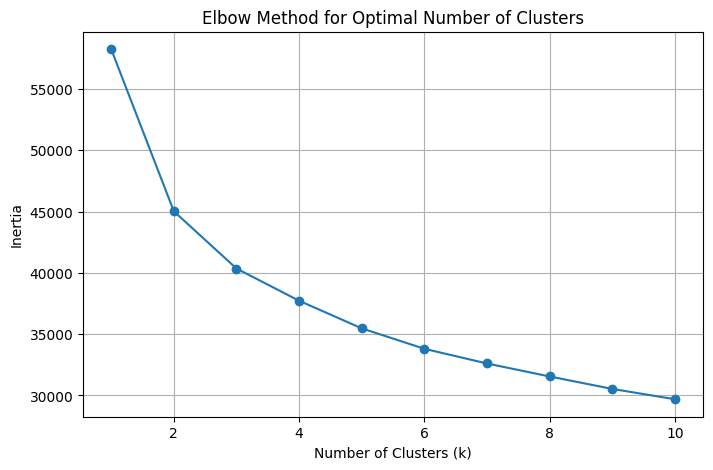

In [7]:
# Elbow Method
# Determine the Optimal Number of Clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

The Elbow Method was used to determine the optimal number of clusters by examining the relationship between the number of clusters and the within-cluster sum of squares (inertia). The inertia decreases substantially as the number of clusters increases from one to five, after which the rate of improvement begins to slow. This indicates diminishing returns from adding additional clusters beyond this point. Therefore, five clusters were selected for the K-Means analysis because they provide a suitable balance between capturing meaningful patterns in the hurricane data and maintaining a relatively simple clustering structure.

In [ ]:
# Fit the K-Means Model

from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=5,         # Optimal number of clusters selected using the Elbow Method
    random_state=42,
    n_init=10
)
cluster_data["Cluster"] = kmeans.fit_predict(X_scaled)

#  Display the number of hurricane observations assigned to each cluster
cluster_data["Cluster"].value_counts().sort_index()

Cluster
0     880
1    1124
2     926
3     296
4     657
Name: count, dtype: int64

The K-Means algorithm successfully partitioned the hurricane observations into five distinct clusters based on the selected temporal, geographic, storm-size, and environmental predictors. The resulting clusters are not equal in size, which is expected because K-Means groups observations according to similarities in the selected features rather than forcing equal-sized groups.

Cluster 1 contains the largest number of observations (1,124), indicating that many hurricanes share similar temporal, geographic, storm-size, and environmental characteristics. In contrast, Cluster 3 is the smallest group (296 observations), suggesting that it represents a more distinct subset of hurricanes with less common characteristics. The remaining clusters contain between 657 and 926 observations, demonstrating that the selected predictors naturally partition hurricanes into several meaningful groups with varying levels of representation.

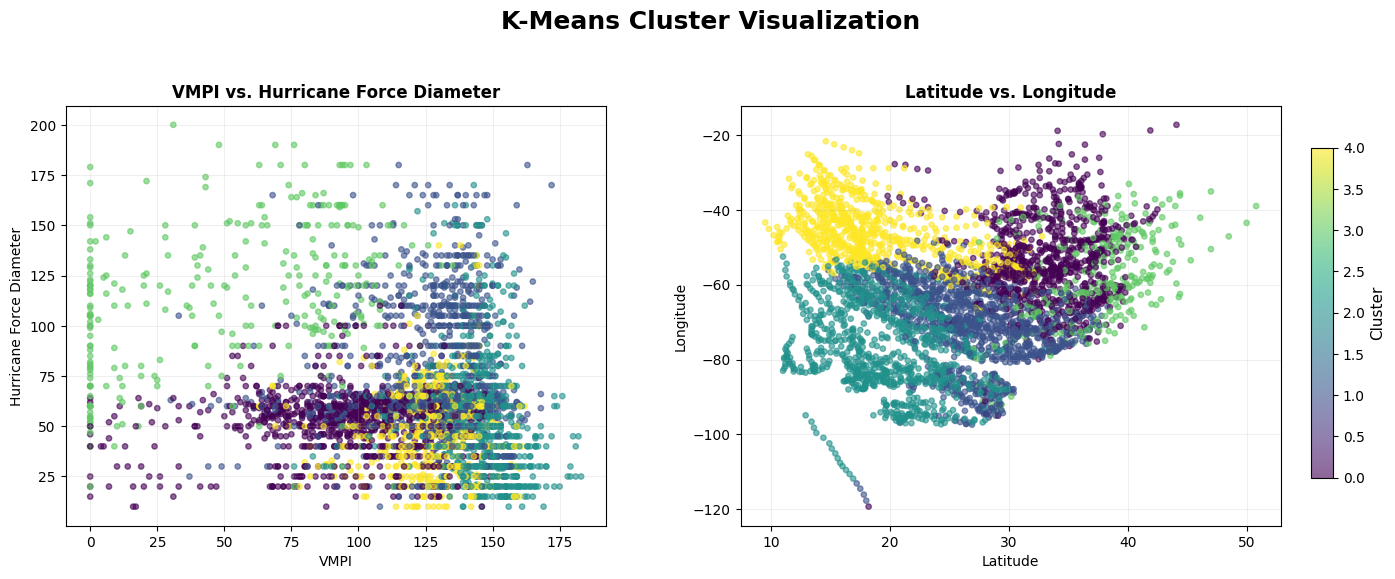

In [ ]:
# Visualize the K-Means Clusters
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: VMPI vs. Hurricane Force Diameter
scatter = axes[0].scatter(
    cluster_data["VMPI"],
    cluster_data["hurricane_force_diameter"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    alpha=0.6,
    s=15
)

axes[0].set_title(
    "VMPI vs. Hurricane Force Diameter",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_xlabel("VMPI")
axes[0].set_ylabel("Hurricane Force Diameter")
axes[0].grid(alpha=0.2)

# Plot 2: Latitude vs. Longitude
axes[1].scatter(
    cluster_data["lat"],
    cluster_data["long"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    alpha=0.6,
    s=15
)

axes[1].set_title(
    "Latitude vs. Longitude",
    fontsize=12,
    fontweight="bold"
)
axes[1].set_xlabel("Latitude")
axes[1].set_ylabel("Longitude")
axes[1].grid(alpha=0.2)

# Figure Title

fig.suptitle(
    "K-Means Cluster Visualization",
    fontsize=18,
    fontweight="bold"
)

# Adjust subplot spacing
fig.subplots_adjust(
    left=0.07,
    right=0.88,
    bottom=0.12,
    top=0.82,
    wspace=0.25
)

# Dedicated Colorbar
cbar_ax = fig.add_axes([0.90, 0.20, 0.015, 0.55])

cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label("Cluster", fontsize=11)

plt.show()

K-Means Cluster Visualization

The K-Means cluster visualizations present the clustering results using two representative feature pairs from the final predictor set. The first plot compares Ventilation-Adjusted Maximum Potential Intensity (VMPI) with hurricane-force diameter, illustrating how storms with similar environmental conditions and storm sizes are grouped into clusters. While some overlap exists among the clusters, several distinct groupings are visible, indicating that differences in storm intensity potential and storm size contribute to the clustering structure.

The second plot illustrates the geographic distribution of hurricanes using latitude and longitude. The visualization shows that hurricanes from different geographic regions tend to form separate groups, although some overlap remains because hurricane characteristics vary continuously across locations. Since K-Means clustering was performed using all selected predictors simultaneously, each scatter plot provides only a two-dimensional representation of the overall clustering solution. Together, these visualizations demonstrate that the selected temporal, geographic, storm-size, and environmental predictors effectively capture meaningful similarities among hurricane observations.

**Hierarchical Clustering**

Hierarchical clustering was performed to further examine the natural grouping of hurricanes. Unlike K-Means, hierarchical clustering does not require specifying the number of clusters in advance. Instead, it builds a hierarchy of clusters by successively merging the most similar observations. The resulting dendrogram provides a visual representation of how hurricanes are grouped based on their similarities.

In [19]:
# Import Libraries for Hierarchical Clustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute the Linkage Matrix
linked = linkage(X_scaled, method="ward")

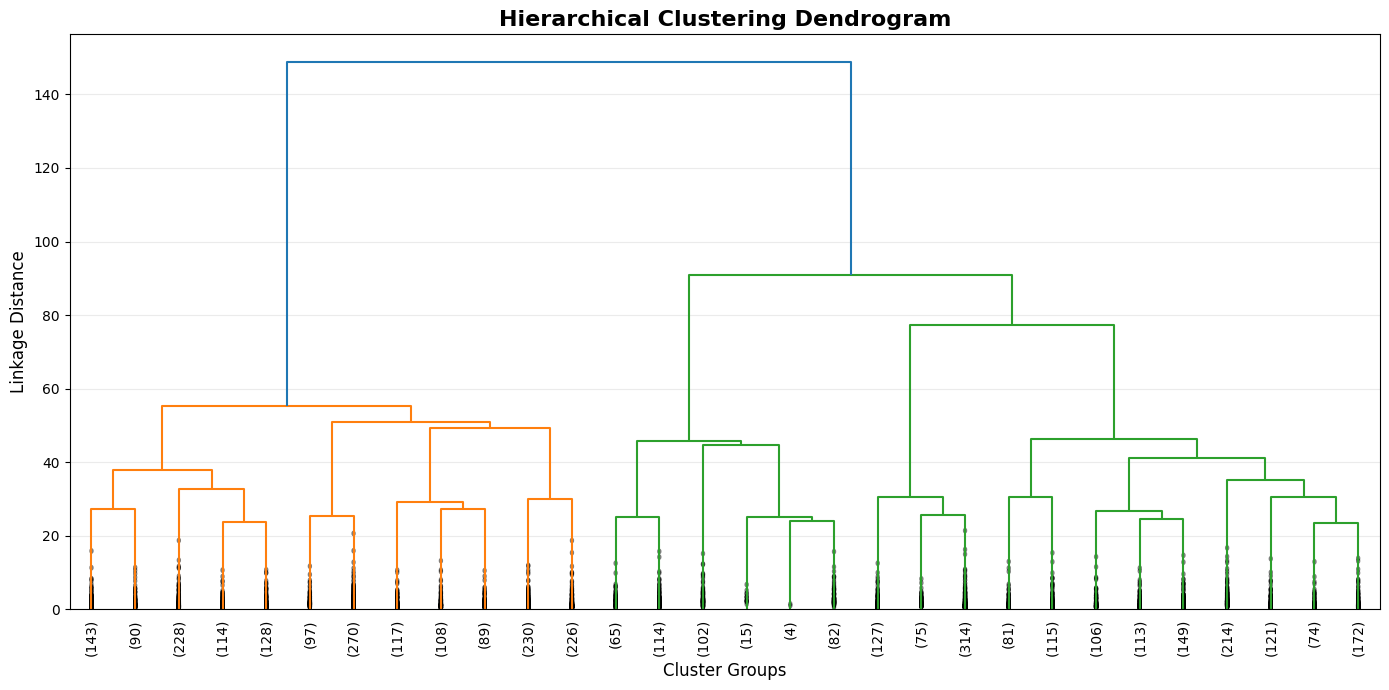

In [20]:
# Plot the Hierarchical Clustering Dendrogram
plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title(
    "Hierarchical Clustering Dendrogram",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Cluster Groups", fontsize=12)
plt.ylabel("Linkage Distance", fontsize=12)

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

The hierarchical clustering dendrogram illustrates how hurricane observations are progressively merged into larger clusters based on similarities in the selected temporal, geographic, storm-size, and environmental predictor variables. The vertical axis represents the linkage distance, where shorter branches indicate more similar observations and taller branches represent greater differences between clusters.

The dendrogram reveals several distinct cluster groupings before the final merges occur, indicating that hurricanes naturally form multiple groups based on their overall characteristics. Most observations merge at relatively low linkage distances, while the final merge occurs at a substantially higher linkage distance, suggesting that the largest groups remain distinct until the final stage of the clustering process. These findings support the K-Means results and provide additional evidence that the hurricane dataset contains meaningful underlying cluster structure.

**Why use Hierarchical Clustering if you already used K-Means?**

K-Means requires the number of clusters to be specified in advance, whereas Hierarchical Clustering builds a hierarchy of relationships without making that assumption. The dendrogram provides a visual representation of how hurricane observations group together across multiple levels of similarity and serves as a complementary validation of the clustering patterns identified by K-Means. Using both methods strengthens the analysis by confirming that the selected temporal, geographic, storm-size, and environmental predictors consistently reveal meaningful natural groupings within the hurricane dataset.

**Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) was performed to reduce the dimensionality of the hurricane dataset while preserving as much of the original variation as possible. Using the final predictor set selected through the feature selection analysis, PCA transformed the standardized variables into a smaller set of uncorrelated principal components, making it easier to visualize the underlying structure of the data. The principal components were then used to display the hurricane clusters identified by the K-Means algorithm in two dimensions.

In [21]:
# Import PCA
from sklearn.decomposition import PCA

# Perform Principal Component Analysis (PCA)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

In [23]:
# Calculate the Explained Variance
explained_variance = pca.explained_variance_ratio_

print("Principal Component 1:", explained_variance[0])
print("Principal Component 2:", explained_variance[1])
print("Total Explained Variance:", explained_variance.sum())

Principal Component 1: 0.324815905030733
Principal Component 2: 0.14679030049486055
Total Explained Variance: 0.4716062055255935


The first principal component explains approximately 32.48% of the total variance in the dataset, while the second principal component explains approximately 14.68%. Together, the first two principal components account for approximately 47.16% of the overall variation contained in the selected predictor variables. Although the first two components do not capture all of the information in the original dataset, they retain a substantial proportion of the variability and provide an effective two-dimensional representation for visualizing the clustering structure.

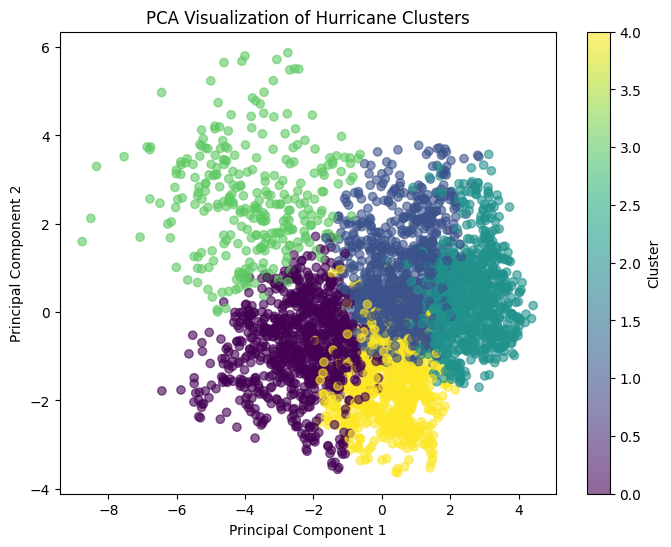

In [25]:
# PCA Scatter Plot
# Create a DataFrame with the Principal Components

import pandas as pd
import matplotlib.pyplot as plt

pca_df = pd.DataFrame(
    principal_components,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Cluster"] = cluster_data["Cluster"]

# Visualize the PCA Results

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("PCA Visualization of Hurricane Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()



The PCA scatter plot displays the hurricane observations using the first two principal components, which together explain approximately 47.16% of the total variance in the selected predictor variables. Although reducing the dataset to two dimensions does not capture all of the original variability, it provides a meaningful low-dimensional representation that makes it easier to visualize the overall cluster structure while retaining a substantial proportion of the information contained in the dataset.

The visualization shows that the five K-Means clusters form several distinguishable groups, although moderate overlap exists between some clusters. This overlap is expected because PCA compresses information from the fifteen selected predictor variables into only two principal components. Despite this reduction, the clusters remain reasonably well separated, indicating that the K-Means algorithm successfully identified meaningful patterns within the hurricane dataset. Overall, the PCA results support the findings from both the K-Means and Hierarchical Clustering analyses by demonstrating that the selected temporal, geographic, storm-size, and environmental predictors capture meaningful similarities among hurricane observations.

**Conclusion**

Unsupervised learning techniques were successfully applied to identify natural patterns within the hurricane dataset using the final predictor set selected through the feature selection analysis. The Elbow Method indicated that five clusters provided an appropriate balance between model simplicity and cluster separation. K-Means clustering grouped hurricanes according to similarities in their temporal, geographic, storm-size, and environmental characteristics, while Hierarchical Clustering produced a dendrogram that confirmed the presence of several distinct natural groupings. Principal Component Analysis reduced the fifteen selected predictor variables into two principal components that explained approximately 47.16% of the total variance, providing an effective two-dimensional visualization of the clustering structure. Together, these methods demonstrated that hurricanes exhibit meaningful natural groupings based on the selected predictor variables without relying on predefined hurricane category labels.